# GRAFIKA KOMPUTEROWA LAB_0
**Imię Nazwisko, nr albumu**

## 1. CEL ĆWICZENIA
Zapoznanie się z podstawowymi cechami środowiska Python i przykładami popularnych instrukcji.

In [13]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

## 2.1. Generowanie i reprezentacja danych/zmiennych
Przykłady deklaracji (i nadawania wartości) zmiennym.

In [14]:
x = 2.1
y = 2.1 + 3.3j
print('x =', x)
print('y =', y)

x = 2.1
y = (2.1+3.3j)


In [15]:
X  = np.array([1, 4, 6])
Y  = np.array([[1], [4], [6]])
Y  = X.reshape(-1, 1)
YY = np.array([[1, 4, 6], [5, 6, 9]])

print('X  =', X)
print('Y  =\n', Y)
print('YY =\n', YY)

X  = [1 4 6]
Y  =
 [[1]
 [4]
 [6]]
YY =
 [[1 4 6]
 [5 6 9]]


Wygeneruj dane opisane funkcją sin w zakresie od $-\pi$ do $+\pi$ z przyrostem argumentu równym $0.01$ (wykres wygląda wówczas jak ciągły).
Wygeneruj dane losowe w tym samym zakresie i z tym samym przyrostem, wartości danych powinny oscylować między $-0.5$ i $+0.5$.

In [16]:
t  = np.arange(-np.pi, np.pi, 0.01)
x1 = np.sin(t)
n  = len(t)
x2 = -0.5 + np.random.rand(n)

## 2.2. Działania na macierzach

In [17]:
X  = np.array([1, 4, 6])
Y  = X.reshape(-1, 1)
A  = np.array([[1, 2, 1], [4, 5, 6], [7, 8, 9]], dtype=float)
B  = np.array([[9, 8, 7], [6, 5, 4], [1, 2, 1]], dtype=float)

XY     = X @ Y
YX     = Y @ X.reshape(1, -1)
AplusB = A + B
AmmB   = A @ B
AmiB   = A * B
AdiB   = A / B
AdmB   = A @ np.linalg.inv(B)
AddB   = A @ np.linalg.inv(B)

print('XY     =', XY)
print('YX     =\n', YX)
print('A+B    =\n', AplusB)
print('A*B    =\n', AmmB)
print('A.*B   =\n', AmiB)
print('A./B   =\n', AdiB)
print('A/B    =\n', AdmB)
print('A*invB =\n', AddB)

XY     = [53]
YX     =
 [[ 1  4  6]
 [ 4 16 24]
 [ 6 24 36]]
A+B    =
 [[10. 10.  8.]
 [10. 10. 10.]
 [ 8. 10. 10.]]
A*B    =
 [[ 22.  20.  16.]
 [ 72.  69.  54.]
 [120. 114.  90.]]
A.*B   =
 [[ 9. 16.  7.]
 [24. 25. 24.]
 [ 7. 16.  9.]]
A./B   =
 [[0.11111111 0.25       0.14285714]
 [0.66666667 1.         1.5       ]
 [7.         4.         9.        ]]
A/B    =
 [[ 0.00000000e+00  2.22044605e-16  1.00000000e+00]
 [ 3.33333333e+00 -4.33333333e+00  7.77156117e-16]
 [ 4.33333333e+00 -5.33333333e+00  7.21644966e-16]]
A*invB =
 [[ 0.00000000e+00  2.22044605e-16  1.00000000e+00]
 [ 3.33333333e+00 -4.33333333e+00  7.77156117e-16]
 [ 4.33333333e+00 -5.33333333e+00  7.21644966e-16]]


## 2.3. Grafika
W przypadku kreślenia (wizualizacji) danych 1D, np. szeregów czasowych, postępujemy zazwyczaj w następujący (lub podobny) sposób:

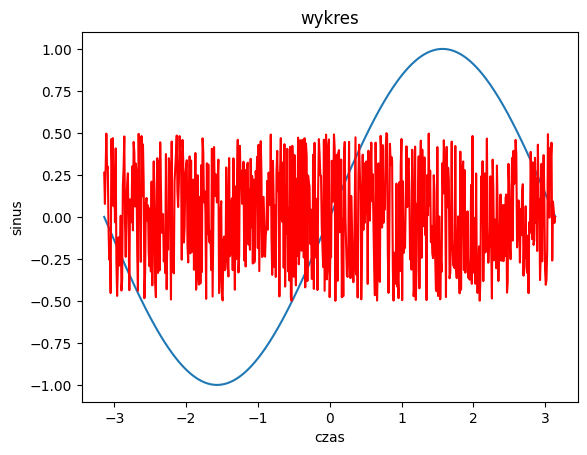

In [18]:
fig1, ax1 = plt.subplots()
ax1.plot(t, x1)
ax1.plot(t, x2, color='red')
ax1.set_title('wykres')
ax1.set_xlabel('czas')
ax1.set_ylabel('sinus')
plt.show()

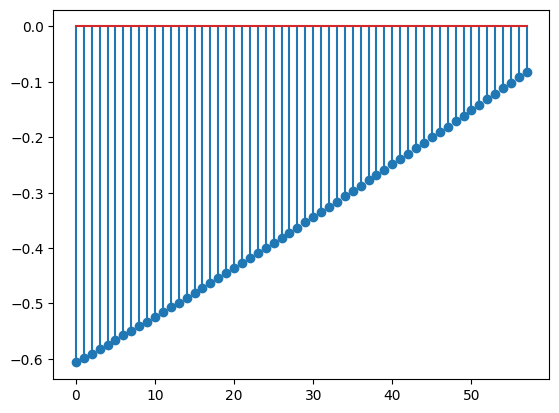

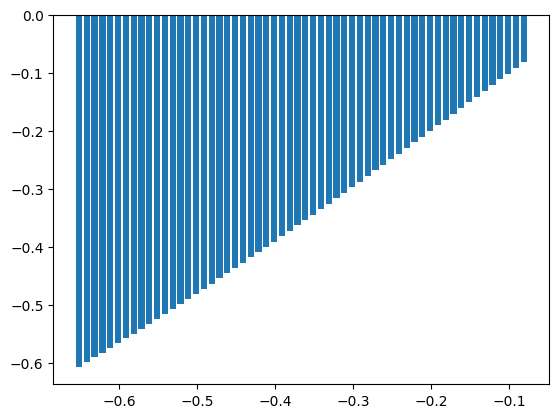

In [19]:
fig2, ax2 = plt.subplots()
ax2.stem(x1[249:307])
plt.show()

fig3, ax3 = plt.subplots()
ax3.bar(t[249:307], x1[249:307], width=0.008)
plt.show()

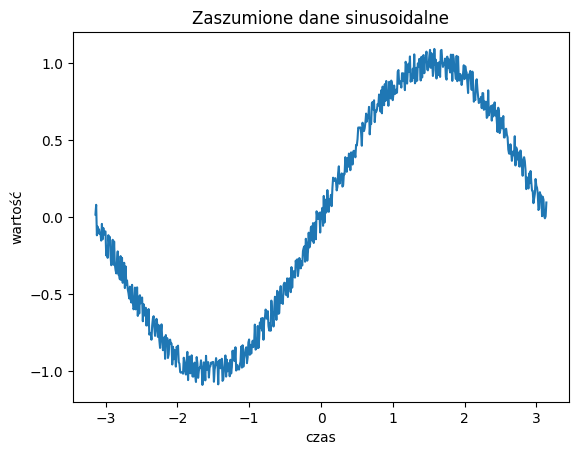

In [20]:
x3 = x1 - 0.1 + 0.2 * np.random.rand(n)

fig4, ax4 = plt.subplots()
ax4.plot(t, x3)
ax4.set_title('Zaszumione dane sinusoidalne')
ax4.set_ylabel('wartość')
ax4.set_xlabel('czas')
plt.show()

## 2.4. Dane obrazowe
Python akceptuje (w sensie czytania i zapisu) obrazy w bardzo wielu formatach (jpg, gif, bmp, png, itd.) ale ich wewnętrzna reprezentacja jest zawsze taka sama.

In [21]:
from PIL import Image

ImCol  = np.zeros((128, 128, 3), dtype=np.uint8)
ImGray = np.zeros((128, 128),    dtype=np.uint8)

Typowa sekwencja wczytania, przetwarzania, wyświetlania i zapisu obrazu:

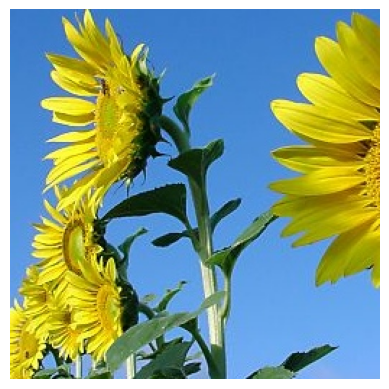

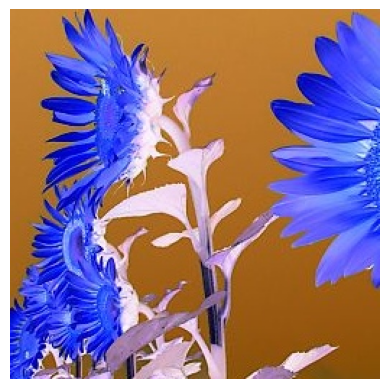

In [22]:
Im = np.array(Image.open('obraz.bmp'))

fig5, ax5 = plt.subplots()
ax5.imshow(Im)
ax5.axis('off')
plt.show()

ImZ = Im.astype(np.float64)
ImZ = 255 - ImZ

fig6, ax6 = plt.subplots()
ax6.imshow(ImZ / 255)
ax6.axis('off')
plt.show()

ImNew = ImZ.astype(np.uint8)
Image.fromarray(ImNew).save('obraz_nowy.jpg')

> **Dlaczego dzielimy przez 255?** Funkcja `imshow` oczekuje wartości zmiennoprzecinkowych w zakresie $[0.0,\ 1.0]$.

## 2.5. Animacje (tworzenie, odczyt i zapis)
Typowa sekwencja odczytu i zapisu pliku wideo:

In [23]:
import imageio

reader = imageio.get_reader('film_01.avi')
fps    = reader.get_meta_data()['fps']
writer = imageio.get_writer('film_01.mp4', fps=fps)

for klatka in reader.iter_data():
    h, w    = klatka.shape[:2]
    klatka1 = np.array(Image.fromarray(klatka).resize((w//2, h//2)))
    writer.append_data(klatka1)

writer.close()

IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (160, 90) to (160, 96) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


## 2.6. Funkcje
Przykłady użycia funkcji:

In [24]:
def dodaj(b, c):
    return b + c

b  = 25
c  = 75
a  = dodaj(b, c)
print('a  =', a)

b1 = 4.567
c1 = 1.017 + 1j * 0.589
a1 = dodaj(b1, c1)
print('a1 =', a1)

a  = 100
a1 = (5.584+0.589j)


## Typowy koniec skryptu

In [25]:
plt.close('all')